# Procrustes across cortical regions in the IBL Brainwide Map

Figure-3-style analysis of the shape-metrics paper, applied to Posani, Wang et al. (2026),
*Rarely categorical, highly separable representations along the cortical hierarchy*.

In their Fig. 2c the single-neuron selectivity profiles are **averaged** within each region.
Here we keep the whole population of each region and compare regions with the Procrustes
shape distance instead.

Five analyses, then one summary figure:

1. shape distances between regions
2. the geometry predicts the cortical hierarchy
3. the distances track anatomical connectivity
4. the region space is a continuum, not a set of categories
5. which task variables the distances encode

Sections 1-5 compute and print; every panel is drawn once, in section 6. All the work happens
in `code/`. Run `extract_selectivity.py` once first to produce `rrr_neurons.npz`.

In [1]:

from shapemetrics import paths

paths.set_figure("Figure2")
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from shapemetrics import plotting

_c = paths.figure_code("Figure2")

data, shape = _c.data, _c.shape

d = data.Dataset()
print(d)
print(", ".join(f"{a}({n})" for a, n in zip(d.regions, d.counts)))

Dataset(4617 selective neurons, 22 regions)
VISp(160), AUDp(164), SSp-ll(74), SSp-n(191), SSp-ul(100), SSp-m(465), SSp-bfd(185), SSs(269), SSp-tr(92), MOp(754), RSPv(87), RSPd(68), GU(76), ORBl(67), AId(144), VISpm(77), PL(103), VISa(316), VISam(76), MOs(383), ORBvl(121), ACAd(120)


## 1. Shape distances between regions

Each region gives a *conditions x neurons* matrix. In `temporal` mode the conditions are
the 8 task variables x 100 time bins of the RRR encoding model, so a column is one neuron's
tuning. Each matrix is reduced to 25 PCs and normalised, then

$$d(X, Y) = \min_{Q\ \mathrm{orthogonal}} \lVert X - YQ \rVert_F$$

Every region is subsampled to 50 neurons, 20 times, and the distances averaged. Splitting a
region against itself gives the noise floor that a between-region distance has to beat.

In [2]:
D = shape.distance_matrix(d, mode="temporal", n_pcs=25, n_sub=50, n_repeats=20)

within = shape.split_half(d, mode="temporal", n_pcs=25, n_sub=50, n_repeats=20)
print(f"within-region (split-half): {within.mean():.3f}")
print(f"across regions:             {shape.pairs(D).mean():.3f}")

within-region (split-half): 0.602
across regions:             0.711


## 2. The geometry predicts the cortical hierarchy

`shape.embed` and `shape.classical_mds` use classical MDS: a closed form, so the coordinates
come out the same every run. sklearn's `MDS` (SMACOF) preserves the distances just as well but
starts from a random configuration, and the individual coordinates change from run to run --
which matters here, where they are used as regressors.

Cross-validation is leave-one-region-out, so a region's own distances never help predict it.
Several estimators are compared because the full 21-dimensional embedding has far more
predictors than the 22 regions can support; ridge is the one carried into the summary.

In [3]:
h = d.hierarchy()                                            # position along the hierarchy
xy, var = shape.embed(D, n_components=10)                    # 2D, for the summary panel
E = shape.classical_mds(D, n_components=len(d.regions) - 1)  # the matrix, losslessly
ALPHAS = np.logspace(-6, 6, 49)

from sklearn.linear_model import LassoCV
fits = {
    "PC1 + PC2":                 shape.cv_regress(E[:, :2], h),
    "full, least squares":       shape.cv_regress(E, h),
    "full, ridge":               shape.cv_regress(E, h, alphas=ALPHAS),
    "full, lasso":               shape.cv_regress(E, h, model=lambda: LassoCV(cv=5, max_iter=50000)),
    "truncation chosen in-fold": shape.cv_regress_truncated(E, h)[:3],
}
for name, (_, r2, rho) in fits.items():
    print(f"  {name:26s} LOO R2 = {r2:+.3f}   rho = {rho:+.2f}")

ridge_cv, r2_hier, rho_hier = shape.cv_regress(E, h, alphas=ALPHAS)
rng = np.random.default_rng(0)
null_r2 = np.array([shape.cv_regress(E, rng.permutation(h), alphas=ALPHAS)[1]
                    for _ in range(200)])
p_hier = (np.sum(null_r2 >= r2_hier) + 1) / (len(null_r2) + 1)
print(f"\nridge on the full matrix: LOO R2 = {r2_hier:.2f}, rho = {rho_hier:+.2f}, "
      f"p = {p_hier:.3f} (200 hierarchy shuffles)")

  PC1 + PC2                  LOO R2 = +0.495   rho = +0.74
  full, least squares        LOO R2 = +0.395   rho = +0.61
  full, ridge                LOO R2 = +0.390   rho = +0.59
  full, lasso                LOO R2 = +0.270   rho = +0.61
  truncation chosen in-fold  LOO R2 = +0.278   rho = +0.62



ridge on the full matrix: LOO R2 = 0.39, rho = +0.59, p = 0.005 (200 hierarchy shuffles)


## 3. Anatomical connectivity

The target is the log anatomical connectivity between the two regions of a pair, the same
quantity their Fig. 2d relates to averaged selectivity. Cross-validation holds out a whole
region at a time: all 21 pairs that touch it become the test set, so no region is in both the
training and the test set. With a single predictor the regression *is* the correlation.

In [4]:
conn = shape.pairs(d.connectivity())     # log anatomical connectivity of each pair
dist = shape.pairs(D)                    # Procrustes distance of each pair

_, r2_in, _ = shape.regress(dist, conn)
_, r2_conn_cv, rho_conn_cv = shape.cv_regress_pairs(dist, conn, len(d.regions))
rho_conn, p_conn = spearmanr(dist, conn)
print(f"in-sample R2 = {r2_in:.3f}")
print(f"leave-one-region-out R2 = {r2_conn_cv:.3f}, rho(true, predicted) = {rho_conn_cv:+.2f}")
print(f"spearman(distance, connectivity) = {rho_conn:.2f}, p = {p_conn:.1e}")

in-sample R2 = 0.232
leave-one-region-out R2 = 0.191, rho(true, predicted) = +0.47
spearman(distance, connectivity) = -0.51, p = 2.2e-16


## 4. Categorical, or a continuum?

Sections 2 and 3 show the regions are *arranged* meaningfully. That leaves open whether they
fall into discrete groups or lie on a continuum.

Silhouette cannot answer it directly -- it needs at least two clusters, so it can never score
the one-cluster hypothesis. That hypothesis has to be simulated instead. `shape.gaussian_null`
draws points from a *single* Gaussian matched to the real cloud's mean and covariance -- the
real spread, none of the lumpiness -- and sweeps k identically. It is the null Posani et al.
use for neurons, applied here to regions. With 22 regions, k runs to 21 at most.

In [5]:
ks = np.arange(2, len(d.regions))          # 2..21, the maximum for 22 regions
E5 = E[:, :5]                              # the embedding already built in section 2
obs = shape.silhouette_sweep(E5, ks)
null = shape.gaussian_null(E5, ks, n_draw=500)

# Posani's statistic (`kmeans_sort` + `_get_best`): sweep k, keep the best silhouette,
# and let the null make the same free choice of k.
sil = obs.max()
best_null = null.max(1)
z_best = (sil - best_null.mean()) / best_null.std()
p_best = (np.sum(best_null >= sil) + 1) / (len(null) + 1)
print(f"data:  best k = {ks[obs.argmax()]}, silhouette = {sil:.4f}")
print(f"null:  {best_null.mean():.4f} +/- {best_null.std():.4f}"
      f"   z = {z_best:+.2f}, p = {p_best:.3f}")
print(f"       the null picks k = 2 in {np.mean(ks[null.argmax(1)] == 2):.0%} of its draws")

data:  best k = 2, silhouette = 0.2798
null:  0.2614 +/- 0.0389   z = +0.47, p = 0.271
       the null picks k = 2 in 36% of its draws


The statistic is the one Posani et al.'s pipeline uses, and the one behind the
head-direction figure: sweep k, keep the best silhouette, and let the null make the same free
choice of k. Choosing k by `argmax` costs nothing that way, because the null gets the same
licence -- which is why this is a single number compared against a null distribution rather
than a curve over k.

The regions are **not** categorical: best silhouette 0.280 against a null's own best of
0.261 +/- 0.039, **z = +0.47, p = 0.27**. Note also that the null picks k = 2 in 36% of its
own draws, because k-means will halve any elongated cloud -- so the data's winning k = 2 is
weak evidence by itself even before the comparison.

Regions are distinguishable from one another, then, but not *categorical*: a single continuous
cloud with the same covariance reproduces the observed clustering. That is consistent with the
rest of the notebook -- a space organised by a continuous sensory-to-associative gradient is
exactly one that predicts the hierarchy well and partitions badly.

## 4b. Is each region categorical on its own?

Section 4 asked whether the 22 *regions* fall into categories. The question one level down --
whether a region's own neurons do -- is easily conflated with it, so it is run here on the same
data, with the same statistic and the same null.

Each region's neurons go through Posani et al.'s pipeline (standardise each neuron across its
features, PCA to 90% of the variance, sweep k, keep the best mean silhouette), against
`N_DRAWS` Gaussians matched to *that region* and drawn in the ORIGINAL feature space, so the
pipeline's nonlinearity hits data and null alike. That gives one z per region, which is the
histogram in panel b of the summary figure. It is figure 1's `categoricality`, unchanged.

Cached under `results/figure2/`, so a re-run is instant.


In [6]:
from pathlib import Path

import shapemetrics as sm

KLIM, NINIT, N_DRAWS = (2, 11), 10, 25           # figure 1's settings
FIG2 = paths.results("figure2")
FIG2.mkdir(parents=True, exist_ok=True)

f = FIG2 / "region_categoricality.npz"
if f.exists():
    z_cat = np.load(f)["z"]
else:
    F = d.features("temporal")
    rng = np.random.default_rng(0)
    z_cat = []
    for a in d.regions:
        Xa = F[d.neurons(a)]
        o = sm.pipeline_silhouette(Xa, k_lim=KLIM, n_init=NINIT)
        nl = np.array([sm.pipeline_silhouette(sm.curve_gaussian_null(Xa, rng),
                                              k_lim=KLIM, n_init=NINIT)
                       for _ in range(N_DRAWS)])
        z_cat.append((o - nl.mean()) / (nl.std() + 1e-12))
    z_cat = np.array(z_cat)
    np.savez(f, z=z_cat, regions=d.regions)

print(f"{(np.abs(z_cat) > 1.96).sum()}/{len(z_cat)} regions past |z| = 1.96, "
      f"median z = {np.median(z_cat):+.2f}, range {z_cat.min():+.2f} to {z_cat.max():+.2f}")
for a, z_ in sorted(zip(d.regions, z_cat), key=lambda t: -t[1]):
    print(f"  {a:<9} z = {z_:+.2f}")


kmeans_sort:   0%|          | 0/9 [00:00<?, ?it/s]

kmeans_sort: 100%|██████████| 9/9 [00:00<00:00, 233.70it/s]

kmeans_sort:   0%|          | 0/9 [00:00<?, ?it/s]

kmeans_sort: 100%|██████████| 9/9 [00:00<00:00, 253.08it/s]

kmeans_sort:   0%|          | 0/9 [00:00<?, ?it/s]

...

kmeans_sort:   0%|          | 0/9 [00:00<?, ?it/s]

kmeans_sort: 100%|██████████| 9/9 [00:00<00:00, 271.58it/s]

kmeans_sort:   0%|          | 0/9 [00:00<?, ?it/s]

kmeans_sort: 100%|██████████| 9/9 [00:00<00:00, 270.72it/s]

9/22 regions past |z| = 1.96, median z = +1.29, range -1.32 to +7.28
  VISp      z = +7.28
  RSPd      z = +5.15
  SSp-n     z = +5.09
  SSp-bfd   z = +4.82
  SSp-ul    z = +4.05
  SSs       z = +3.72
  VISam     z = +2.93
  SSp-tr    z = +2.56
  VISpm     z = +2.01
  GU        z = +1.88
  MOs       z = +1.38
  SSp-ll    z = +1.20
  RSPv      z = +0.99
  MOp       z = +0.98
  SSp-m     z = +0.78
  AUDp      z = +0.72
  VISa      z = +0.63
  AId       z = +0.41
  PL        z = -0.72
  ORBvl     z = -0.77
  ORBl      z = -1.25
  ACAd      z = -1.32


## 5. Which variables do the distances encode?

One model, everything competing: the eight task variables plus log anatomical connectivity.
A region's own selectivity helps set where it sits, so regressing one on the other with the
same neurons would be circular -- `shape.distance_and_targets` builds the distance matrix from
one half of each region's neurons and takes the selectivity targets from the other half.

The task variables enter as the absolute difference in selectivity between a pair's two
regions; connectivity is already a pair-level quantity, so it enters directly. The null
permutes region labels across both, which keeps the pair structure intact.

In [7]:
D_split, T_split = shape.distance_and_targets(d, n_side=33, n_repeats=20)
ii, jj = np.triu_indices(len(d.regions), 1)
y_split = shape.pairs(D_split)
y_split = (y_split - y_split.mean()) / y_split.std()

C = d.connectivity()                         # log anatomical connectivity, already pairwise
VARS = list(data.VAR_LIST) + ["connectivity"]

def design(perm):
    """Pair-level predictors under a relabelling of the regions.

    The eight task variables enter as the absolute difference in selectivity between a
    pair's two regions; connectivity is already defined on the pair, so it enters directly.
    Permuting `perm` relabels the regions consistently across both, which destroys the link
    between region identity and distance while leaving the pair structure intact.
    """
    T, Cp = T_split[perm], C[np.ix_(perm, perm)]
    X = np.column_stack([np.abs(T[ii] - T[jj]), shape.pairs(Cp)])
    return (X - X.mean(0)) / X.std(0)

X = design(np.arange(len(d.regions)))
beta = shape.fit(X, y_split).coef_
_, r2_var, rho_var = shape.cv_regress_pairs(X, y_split, len(d.regions))

rng = np.random.default_rng(0)
null_b = np.array([shape.fit(design(rng.permutation(len(d.regions))), y_split).coef_
                   for _ in range(2000)])
pvals = [(np.sum(np.abs(null_b[:, k]) >= abs(b)) + 1) / 2001 for k, b in enumerate(beta)]

# standard errors of the least-squares coefficients
resid = y_split - shape.fit(X, y_split).predict(X)
Xc = np.column_stack([np.ones(len(X)), X])
sigma2 = resid @ resid / (len(y_split) - Xc.shape[1])
se = np.sqrt(np.diag(np.linalg.inv(Xc.T @ Xc)) * sigma2)[1:]

vif = np.diag(np.linalg.inv(np.corrcoef(X.T)))
print(f"leave-one-region-out R2 = {r2_var:.3f}, rho = {rho_var:+.2f}")
print(f"max VIF = {vif.max():.1f}  (coefficients are separable below ~5)\n")
order = np.argsort(-np.abs(beta))
for k in order:
    print(f"  {VARS[k]:<13} beta {beta[k]:+.3f} +/- {se[k]:.3f}   p = {pvals[k]:.4f}")
print(f"\n  Bonferroni threshold for {len(VARS)} coefficients: {0.05/len(VARS):.4f}")

leave-one-region-out R2 = 0.591, rho = +0.74
max VIF = 2.0  (coefficients are separable below ~5)

  lick          beta +0.595 +/- 0.043   p = 0.0005
  outcome       beta +0.220 +/- 0.041   p = 0.0805
  connectivity  beta -0.217 +/- 0.045   p = 0.0370
  block         beta +0.117 +/- 0.041   p = 0.3043
  whisker       beta +0.106 +/- 0.042   p = 0.4638
  side          beta -0.100 +/- 0.053   p = 0.5567
  wheel         beta +0.083 +/- 0.041   p = 0.3743
  choice        beta +0.053 +/- 0.055   p = 0.6772
  contrast      beta -0.018 +/- 0.041   p = 0.8641

  Bonferroni threshold for 9 coefficients: 0.0056


Lick dominates and is the only coefficient past Bonferroni. Connectivity contributes
independently and with the expected sign -- more strongly connected regions have more similar
geometry -- but at p = 0.04 it does not survive correction for nine coefficients, and adding it
moves lick only from +0.65 to +0.60. Max VIF is 2.0, so the coefficients are separable rather
than trading off against one another.

Fitting the predictors separately would have called almost all of them significant: they are
correlated with one another, and only a model in which they compete shows which one carries
the effect.

## 6. Summary figure

The five analyses as six panels: the distance matrix (1), the shape space and the hierarchy
prediction (2), anatomical connectivity (3), the cluster sweep against a continuous cloud (4),
and the competing-variable coefficients (5).

'/Users/joaobarbosa/Dropbox/proton_backup/Neuro/papers/shapemetrics_journalpaper/Figure2/results/summary.pdf'

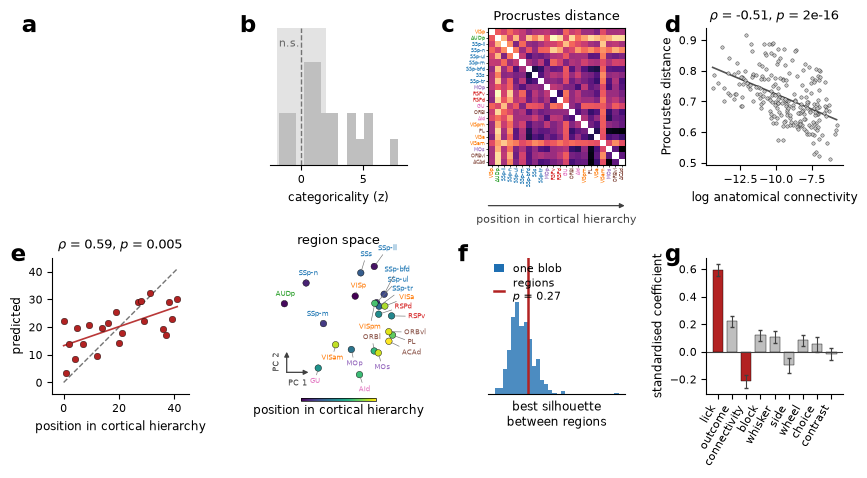

In [8]:
# Drawn in figure 1's style throughout: `code/plotting.py` carries its palette
# (blue is always a null, firebrick always the data), its small black-edged
# markers, and its single typographic scale -- which `plotting.typeset` applies to
# the whole figure in one pass at the end rather than panel by panel, since a
# figure typeset panel by panel drifts.
#
# 2 x 4.  Row 1: a panel left empty for the schematic, per-region categoricality,
# the distance matrix, and connectivity.  Row 2: the region-space test, then the
# region space and the hierarchy it predicts (sharing one letter, since they are
# one argument), and the coefficients.
PANEL = 2.55
fig = plt.figure(figsize=(4 * PANEL, 2 * PANEL))
gs = fig.add_gridspec(2, 4, wspace=.60, hspace=.40)

ax_schem = fig.add_subplot(gs[0, 0])       # a -- left empty, filled in by hand
ax_cat = fig.add_subplot(gs[0, 1])         # b -- per-region categoricality
ax_mat = fig.add_subplot(gs[0, 2])         # c -- the distance matrix
ax_conn = fig.add_subplot(gs[0, 3])        # d -- distance vs connectivity
ax_hier = fig.add_subplot(gs[1, 0])        # e -- the hierarchy region space predicts
ax_emb = fig.add_subplot(gs[1, 1])         # e -- region space itself
ax_sil = fig.add_subplot(gs[1, 2])         # f -- the region-space test
ax_beta = fig.add_subplot(gs[1, 3])        # g -- the coefficients

# a -- reserved: drawn on by hand in Affinity
ax_schem.set_box_aspect(1)
ax_schem.set(xticks=[], yticks=[])
for s in ax_schem.spines.values():
    s.set_visible(False)

# b -- is each region categorical on its own?  One z per region, against a
# Gaussian matched to that region and pushed through the identical pipeline.
plotting.categoricality_hist(ax_cat, z_cat)

# c -- the distance matrix.  The diagonal is masked: it is zero by definition and
# would otherwise clip to the darkest colour and dominate the panel.
plotting.distmat(D, d, ax=ax_mat,
                 axis_note="position in cortical hierarchy")
ax_mat.set_title("Procrustes distance")

# d -- distance against anatomical connectivity.  One point per PAIR of regions,
# so these are the small grey markers and not the region-sized ones.
plotting.scatter(conn, dist, "log anatomical connectivity", "Procrustes distance",
                 ax=ax_conn,
                 title=f"$\\rho$ = {rho_conn:.2f}, $p$ = {p_conn:.0e}")

# e -- what region space predicts: the held-out test, with a whole region left
# out so its own distances never help predict it.
plotting.prediction(h, [ridge_cv], ["leave-one-region-out ridge"], ax=ax_hier,
                    xlabel="position in cortical hierarchy", ylabel="predicted",
                    legend=False,
                    title=f"$\\rho$ = {rho_hier:.2f}, $p$ = {p_hier:.3f}")

# e (continued, no letter of its own) -- the space that prediction was made in.
# Square, so the embedding is not distorted; the region names are pushed apart by
# `plotting.label_points`, which draws a hairline back to any name that had to
# travel to find room.
# `rotate` swings two names the solver sent into their neighbours: MOs clockwise
# off ORBl, SSp-bfd anticlockwise off the SSp-ul / VISpm pile, and ORBl turned
# right round so it sits inside the cloud rather than out on its margin, as
# is VISpm, which the outward rule sent into the middle of the SSp pile.
plotting.mds(xy, var, d, ax=ax_emb, by="hierarchy",
             rotate={"MOs": -40, "SSp-bfd": 40, "ORBl": 180, "VISpm": 180})
ax_emb.set_title("region space")

# f -- continuum or types, in region space.  The x axis is stripped: a
# silhouette's absolute value depends on the number of points and on the
# dimensionality, so only its position within its OWN null reads.  p goes in the
# legend, as in figure 1 -- a free-floating annotation lands on the histogram
# whenever the observed value sits near the null, which here it does.
plotting.null_hist(ax_sil, sil, best_null, "best silhouette\nbetween regions",
                   label_null="one blob", label_obs="regions", p=p_best,
                   strip_xticks=True)

# g -- which variables the distances encode
plotting.coefficients(ax_beta, beta, se, VARS, pvals)

for ax, letter, dx in ((ax_schem, "a", -22), (ax_cat, "b", -22),
                       (ax_mat, "c", -34), (ax_conn, "d", -30),
                       (ax_hier, "e", -30), (ax_sil, "f", -22),
                       (ax_beta, "g", -30)):
    # the matrix carries a column of region names, so its letter clears more room
    plotting.panel_letter(ax, letter, dx=dx)
plotting.typeset(fig)
plotting.save(fig, "summary")